# Content Understanding: calling `prebuilt-layout`

How Azure Content Understanding is called, and what the response contains, using one certificate from `raw-docs/`. Each section takes one part of the JSON and, where that part has a position, draws it on the page.

The Python SDK [`azure-ai-contentunderstanding`](https://learn.microsoft.com/en-us/python/api/overview/azure/ai-contentunderstanding-readme?view=azure-python) wraps the [REST API (2025-11-01)](https://learn.microsoft.com/en-us/rest/api/contentunderstanding/content-analyzers?view=rest-contentunderstanding-2025-11-01). Argument and field names follow that reference.

- [Content Understanding docs](https://learn.microsoft.com/en-us/azure/ai-services/content-understanding/overview)

Analyze calls are billed per page. The cells below analyze one page only (`content_range=str(PAGE)`).

To try another certificate, set `PDF_PATH` and `PAGE` in Setup.

## 1. What is Content Understanding?

You send a **file** to an **analyzer**; the service returns **JSON**.

```
raw-docs/EUR-472273.pdf  ──►  analyzer "prebuilt-layout"  ──►  AnalysisResult (JSON)
                                                                 └─ contents[0]
                                                                     ├─ markdown
                                                                     ├─ pages[] → words[], lines[]
                                                                     ├─ paragraphs[]
                                                                     ├─ tables[] → cells[]
                                                                     └─ figures[]
```

An **analyzer** is a named, pre-configured pipeline. Main families:

| Analyzer | What it does | Needs an LLM deployment? |
|---|---|---|
| `prebuilt-read` | OCR only: words, lines | No |
| **`prebuilt-layout`** | OCR + structure: paragraphs, sections, **tables**, figures | **No** |
| `prebuilt-document` | Base analyzer that custom analyzers extend | n/a |
| `prebuilt-documentSearch` | Layout + summaries, tuned for RAG | Yes |
| `prebuilt-invoice`, `prebuilt-receipt`, … | Domain field extraction | Yes |
| custom analyzer | Your own field schema (e.g. heat number, cert type) | Yes |

This repo uses **`prebuilt-layout`**: no GPT deployment, and every table cell has a row/column position, so a spec limit can be separated from a measured result.

## 2. The endpoint and the API spec

**Endpoint:** `https://<your-resource>.services.ai.azure.com/` (Foundry / AI Services resource) &nbsp;·&nbsp;
**API version:** `2025-11-01` (GA) &nbsp;·&nbsp;
**Auth:** header `Ocp-Apim-Subscription-Key: <key>` *or* Microsoft Entra ID token (scope `https://cognitiveservices.azure.com/.default`)

Used in this notebook:

| Purpose | REST call | SDK method |
|---|---|---|
| Describe an analyzer | `GET /contentunderstanding/analyzers/{analyzerId}` | `client.get_analyzer(...)` |
| Analyze a local file (bytes in body) | `POST /contentunderstanding/analyzers/{analyzerId}:analyzeBinary` | `client.begin_analyze_binary(...)` |
| Poll for the result | `GET /contentunderstanding/analyzerResults/{operationId}` | `poller.result()` |

Also available (not called here):

| Purpose | REST call | SDK method |
|---|---|---|
| List analyzers | `GET /contentunderstanding/analyzers` | `client.list_analyzers()` |
| Analyze a file by URL (JSON body `inputs[]`) | `POST /contentunderstanding/analyzers/{analyzerId}:analyze` | `client.begin_analyze(...)` |

All calls append `?api-version=2025-11-01`.

**Analysis is asynchronous** (a long-running operation):

1. `POST …:analyzeBinary` → **202 Accepted** with an `Operation-Location` header
2. `GET` that URL until `status` is `Succeeded` (or `Failed`)
3. The final body holds `result`, the JSON in the cells below. Results are kept for 24 hours.

The SDK `poller` does steps 2-3.

Reference pages: [Analyze Binary](https://learn.microsoft.com/en-us/rest/api/contentunderstanding/content-analyzers/analyze-binary?view=rest-contentunderstanding-2025-11-01) ·
[Analyze](https://learn.microsoft.com/en-us/rest/api/contentunderstanding/content-analyzers/analyze?view=rest-contentunderstanding-2025-11-01) ·
[Get Result](https://learn.microsoft.com/en-us/rest/api/contentunderstanding/content-analyzers/get-result?view=rest-contentunderstanding-2025-11-01) ·
[All operations](https://learn.microsoft.com/en-us/rest/api/contentunderstanding/content-analyzers?view=rest-contentunderstanding-2025-11-01)

## 3. Setup

Prerequisites:

1. A Foundry / AI Services resource with Content Understanding (no model deployments needed for `prebuilt-layout`).
2. `.env` at the repo root:

```env
AZURE_CONTENT_UNDERSTANDING_ENDPOINT=https://<resource>.services.ai.azure.com/
AZURE_CONTENT_UNDERSTANDING_KEY=<key>
```

3. Packages: `pip install azure-ai-contentunderstanding python-dotenv pandas pymupdf pillow`

The setup cell defines `PDF_PATH` and `PAGE`. Change them to try another certificate; the rest of the notebook follows. Text that describes specific values refers to the default file, `EUR-472273.pdf`.

A subscription key is enough for this notebook. Production should use Entra ID (`azure.identity.DefaultAzureCredential`).

In [1]:
import json
import os
from pathlib import Path

import fitz  # PyMuPDF: renders the PDF page as an image
import pandas as pd
from azure.ai.contentunderstanding import ContentUnderstandingClient
from azure.core.credentials import AzureKeyCredential
from azure.core.exceptions import HttpResponseError
from dotenv import load_dotenv
from IPython.display import Markdown, display
from PIL import Image, ImageDraw

# The only two things you need to change
ROOT = Path.cwd() if (Path.cwd() / "raw-docs").is_dir() else Path.cwd().parent  # repo root
PDF_PATH = ROOT / "raw-docs" / "EUR-472273.pdf"  # swap for any PDF
PAGE = 1  # page to analyze (1-based); one page is billed

load_dotenv(ROOT / ".env")
ENDPOINT = os.getenv("AZURE_CONTENT_UNDERSTANDING_ENDPOINT")
KEY = os.getenv("AZURE_CONTENT_UNDERSTANDING_KEY")

# Fail early with a clear message instead of an obscure error later.
if not ENDPOINT or not KEY:
    raise RuntimeError("Set AZURE_CONTENT_UNDERSTANDING_ENDPOINT and AZURE_CONTENT_UNDERSTANDING_KEY in .env at the repo root.")
if not PDF_PATH.is_file():
    raise FileNotFoundError(f"PDF not found: {PDF_PATH}")

client = ContentUnderstandingClient(endpoint=ENDPOINT, credential=AzureKeyCredential(KEY))

print("Endpoint set:", bool(ENDPOINT))  # the URL itself is not printed
print("Key set     :", bool(KEY))
print("PDF         :", PDF_PATH.name, f"({len(fitz.open(PDF_PATH))} pages), analyzing page {PAGE}")

Endpoint set: True
Key set     : True
PDF         : EUR-472273.pdf (11 pages), analyzing page 1


### Helper: draw what the service found

Every element in the response has a `source` string such as `D(1,0.31,0.65,1.68,0.65,1.68,0.95,0.31,0.95)`: page number, then four corner points (x, y) in inches. `show_boxes` turns those into outlines on the page image, so you can see which part of the PDF each piece of JSON describes. It is the only helper in this notebook.

In [2]:
DPI = 100  # picture resolution; coordinates from the API are in inches, so pixels = inches * DPI

def polygons(source: str):
    """Decode 'D(page,x1,y1,...,x4,y4);D(...)' into [(page, [(x, y), ...]), ...]."""
    regions = []
    for part in source.split(";"):
        page_no, *coords = part.strip()[2:-1].split(",")
        points = list(zip(map(float, coords[0::2]), map(float, coords[1::2])))
        regions.append((int(page_no), points))
    return regions

def show_boxes(sources, labels=None, color="blue"):
    """Draw the analyzed page and outline every element given by its `source` string."""
    pix = fitz.open(PDF_PATH)[PAGE - 1].get_pixmap(dpi=DPI)
    img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    draw = ImageDraw.Draw(img)
    for i, src in enumerate(sources):
        for _, points in polygons(src):
            pixels = [(x * DPI, y * DPI) for x, y in points]
            draw.polygon(pixels, outline=color, width=2)
            if labels:
                draw.text(pixels[0], str(labels[i]), fill=color)
    display(img)

## 4. Analyzer definition

`GET /contentunderstanding/analyzers/prebuilt-layout?api-version=2025-11-01`

In [3]:
analyzer = client.get_analyzer("prebuilt-layout")

print("analyzerId     :", analyzer.analyzer_id)
print("baseAnalyzerId :", analyzer.base_analyzer_id)
print("description    :", analyzer.description)
analyzer.as_dict()["config"]

analyzerId     : prebuilt-layout
baseAnalyzerId : prebuilt-document
description    : Extract various content and layout elements such as words, figures, paragraphs, and tables from documents.


{'returnDetails': True,
 'enableOcr': True,
 'enableLayout': True,
 'enableFormula': True,
 'enableFigureDescription': False,
 'enableFigureAnalysis': False,
 'chartFormat': 'chartjs',
 'tableFormat': 'html',
 'enableSegment': False,
 'omitContent': False,
 'segmentPerPage': False,
 'annotationFormat': 'markdown'}

What the `config` flags mean (they decide **which parts of the response exist**):

| Flag | Effect on the response |
|---|---|
| `returnDetails` | Include `pages`, `paragraphs`, `tables`, and the rest, with positions and confidence. Off: mostly `markdown`. |
| `enableOcr` | Read text from scanned pages / images → `words`, `lines`, `paragraphs` |
| `enableLayout` | Detect structure → `tables`, `sections`, `figures` |
| `enableFormula` | Detect math formulas (LaTeX) |
| `tableFormat` | How tables appear **inside `markdown`**: `html` or `markdown` |
| `chartFormat` | How charts appear in markdown (`chartjs`) |
| `enableFigureDescription` / `enableFigureAnalysis` | LLM captions for images/charts. Off here, so no LLM is required. |
| `enableSegment` | Split a document into segments (e.g. one per certificate in a pack) |
| `omitContent` | Drop the extracted content (only useful with fields) |
| `segmentPerPage` | With `enableSegment`, make each page its own segment |
| `annotationFormat` | How annotations (highlights, comments) appear in `markdown` |

Prebuilt analyzers are fixed. Changing these flags means a custom analyzer with `baseAnalyzerId: "prebuilt-document"`.

## 5. Analyze one certificate

`begin_analyze_binary` = REST `POST …/analyzers/{analyzerId}:analyzeBinary` with the PDF bytes as the request body.

| Argument | REST equivalent | Meaning |
|---|---|---|
| `analyzer_id` | path `{analyzerId}` | Which analyzer to run |
| `binary_input` | request body | Raw file bytes |
| `content_type` | `Content-Type` header | MIME type, e.g. `application/pdf` |
| `content_range` | query `range` | Pages to analyze: `"1"`, `"1-3"`, `"1-3,5,9-"` (1-based) |
| `processing_location` | query `processingLocation` | Where data may be processed: `geography`, `dataZone`, `global` |

The file and page come from `PDF_PATH` and `PAGE` in Setup. Only that page is sent for analysis, so one page is billed. The default is page 1 of `EUR-472273.pdf`, the certificate face.

In [4]:
# Starts the analysis (POST ...:analyzeBinary) and returns a poller.
poller = client.begin_analyze_binary(
    analyzer_id="prebuilt-layout",
    binary_input=PDF_PATH.read_bytes(),
    content_type="application/pdf",
    content_range=str(PAGE),  # only this page is analyzed and billed
)
print("Operation id:", poller.operation_id)

# Waits (GET /analyzerResults/{operationId}) until the status is Succeeded.
result = poller.result()
print("Done.")

Operation id: 4d5b6a04-a38d-415b-aa54-532cf1370801


Done.


### The page you sent

Keep this page in mind. Every section below draws what the service found on top of it.

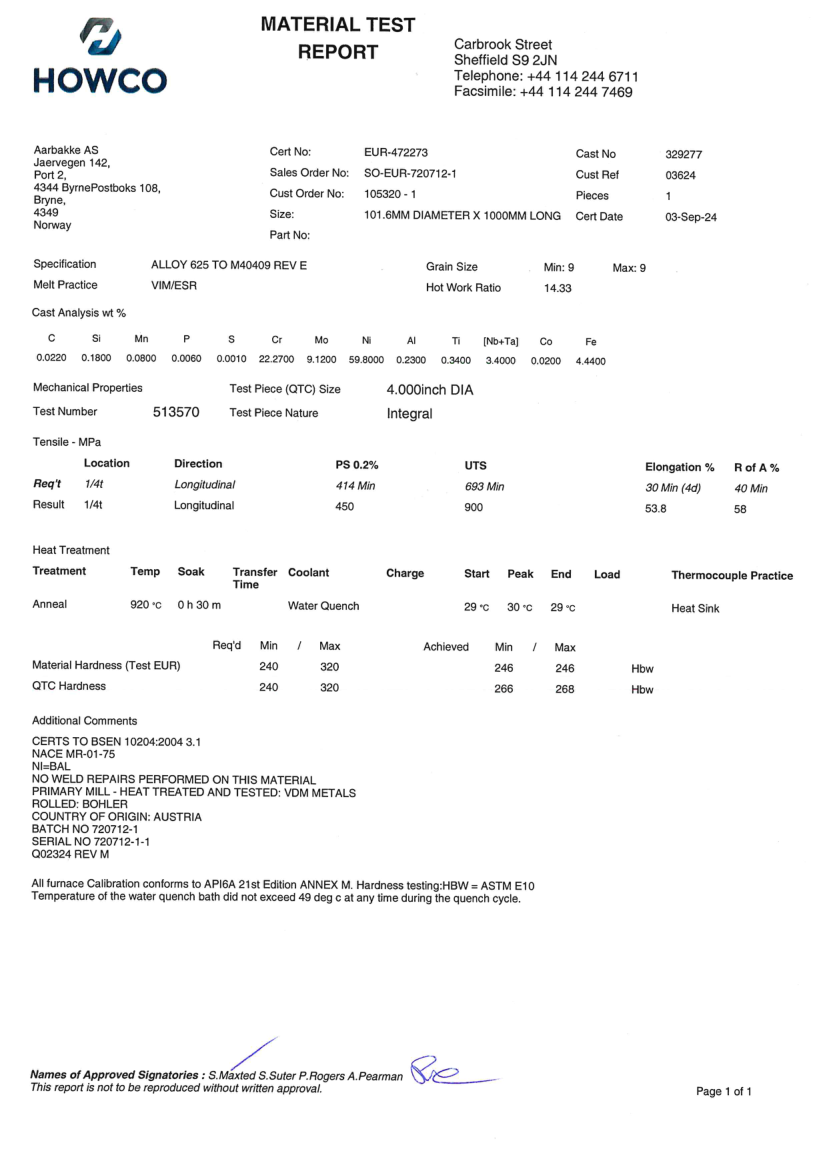

In [5]:
show_boxes([])  # empty list: the page image, no outlines

## 6. The response: top level

`AnalysisResult` (REST: the `result` object of the final poll response):

| Field | Meaning |
|---|---|
| `analyzerId` / `apiVersion` / `createdAt` | Which analyzer and API version produced it, and when |
| `stringEncoding` | How `span` offsets are counted (`codePoint` by default) |
| `warnings` | Non-fatal issues (empty when all is well) |
| `contents[]` | One entry per input. A PDF gives **one** `DocumentContent` (`kind = "document"`) |

> SDK attributes are `snake_case` (`result.analyzer_id`); the JSON is `camelCase` (`analyzerId`).
> `result.as_dict()` returns the raw REST JSON.

The cell below prints every top-level key of the raw JSON.

In [6]:
raw = result.as_dict()

for key, value in raw.items():
    if key == "contents":
        value = f"{len(value)} item(s)"
    print(f"{key:15}: {value}")

analyzerId     : prebuilt-layout
apiVersion     : 2025-11-01
createdAt      : 2026-10-08T16:17:05Z
stringEncoding : codePoint
warnings       : []
contents       : list of 1 item(s), explored below


In [7]:
doc = result.contents[0]  # one file in, one DocumentContent
page = doc.pages[0]       # the page sent in content_range

print("kind        :", doc.kind)
print("mimeType    :", doc.mime_type)
print("pages       :", doc.start_page_number, "to", doc.end_page_number)
print("unit        :", doc.unit.value)
print()

# Optional lists are None when that feature is off. pages is always present: we already indexed it.
pd.Series({
    "pages": len(doc.pages),
    "words": len(page.words or []),
    "lines": len(page.lines or []),
    "paragraphs": len(doc.paragraphs or []),
    "sections": len(doc.sections or []),
    "tables": len(doc.tables or []),
    "figures": len(doc.figures or []),
}, name="count")

kind        : document
mimeType    : application/pdf
pages       : 1 to 1
unit        : inch



pages           1
words         376
lines         153
paragraphs    136
sections        1
tables          7
figures         1
Name: count, dtype: int64

## 7. `markdown`: the whole page as text

The page as Markdown, in reading order.

- Tables are HTML `<table>` blocks (`tableFormat = "html"`).
- Images are `![alt](figures/1.1)`. `1.1` is page 1, figure 1.
- Cell values come from `tables[]`, not from this string.
- The page's `spans` give its exact slice of `markdown`, so no arbitrary cut-off is needed.

First the raw string, then the same text rendered. Images show as broken links because only the reference (`figures/1.1`) is returned, not the image.

In [8]:

# Each page records which slice of `markdown` is its own (offset + length).
span = page.spans[0]
page_markdown = doc.markdown[span.offset : span.offset + span.length]

print(f"page span: offset={span.offset}, length={span.length}\n")
print(page_markdown)

page span: offset=0, length=3248

![HOWCO](figures/1.1)


MATERIAL TEST
REPORT

Carbrook Street
Sheffield S9 2JN
Telephone: +44 114 244 6711
Facsimile: +44 114 244 7469

Aarbakke AS
Jaervegen 142,
Port 2,
4344 ByrnePostboks 108,
Bryne,
4349
Norway

Cert No:

EUR-472273

Cast No

329277

Sales Order No:

SO-EUR-720712-1

Cust Ref

03624

Cust Order No:

105320 - 1

Pieces

1

Size:

101.6MM DIAMETER X 1000MM LONG

Cert Date

03-Sep-24

Part No:


<table>
<tr>
<td>Specification</td>
<td>ALLOY 625 TO M40409 REV E</td>
</tr>
<tr>
<td>Melt Practice</td>
<td>VIM/ESR</td>
</tr>
</table>


<table>
<tr>
<th>Grain Size</th>
<th>Min: 9</th>
<th>Max: 9</th>
</tr>
<tr>
<td>Hot Work Ratio</td>
<td>14.33</td>
<td></td>
</tr>
</table>


Cast Analysis wt %


<table>
<tr>
<th>C</th>
<th>Si</th>
<th>Mn</th>
<th>P</th>
<th>S</th>
<th>Cr</th>
<th>Mo</th>
<th>Ni</th>
<th>AI</th>
<th>Ti</th>
<th>[Nb+Ta]</th>
<th>Co</th>
<th>Fe</th>
</tr>
<tr>
<td>0.0220</td>
<td>0.1800</td>
<td>0.0800</td>
<td>0.0060</td>
<t

In [9]:
display(Markdown(page_markdown))

![HOWCO](figures/1.1)


MATERIAL TEST
REPORT

Carbrook Street
Sheffield S9 2JN
Telephone: +44 114 244 6711
Facsimile: +44 114 244 7469

Aarbakke AS
Jaervegen 142,
Port 2,
4344 ByrnePostboks 108,
Bryne,
4349
Norway

Cert No:

EUR-472273

Cast No

329277

Sales Order No:

SO-EUR-720712-1

Cust Ref

03624

Cust Order No:

105320 - 1

Pieces

1

Size:

101.6MM DIAMETER X 1000MM LONG

Cert Date

03-Sep-24

Part No:


<table>
<tr>
<td>Specification</td>
<td>ALLOY 625 TO M40409 REV E</td>
</tr>
<tr>
<td>Melt Practice</td>
<td>VIM/ESR</td>
</tr>
</table>


<table>
<tr>
<th>Grain Size</th>
<th>Min: 9</th>
<th>Max: 9</th>
</tr>
<tr>
<td>Hot Work Ratio</td>
<td>14.33</td>
<td></td>
</tr>
</table>


Cast Analysis wt %


<table>
<tr>
<th>C</th>
<th>Si</th>
<th>Mn</th>
<th>P</th>
<th>S</th>
<th>Cr</th>
<th>Mo</th>
<th>Ni</th>
<th>AI</th>
<th>Ti</th>
<th>[Nb+Ta]</th>
<th>Co</th>
<th>Fe</th>
</tr>
<tr>
<td>0.0220</td>
<td>0.1800</td>
<td>0.0800</td>
<td>0.0060</td>
<td>0.0010</td>
<td>22.2700</td>
<td>9.1200</td>
<td>59.8000</td>
<td>0.2300</td>
<td>0.3400</td>
<td>3.4000</td>
<td>0.0200</td>
<td>4.4400</td>
</tr>
</table>


<table>
<tr>
<td colspan="2">Mechanical Properties</td>
<td>Test Piece (QTC) Size</td>
<td>4.000inch DIA</td>
</tr>
<tr>
<td>Test Number</td>
<td>513570</td>
<td>Test Piece Nature</td>
<td>Integral</td>
</tr>
</table>


Tensile - MPa


<table>
<tr>
<th></th>
<th>Location</th>
<th>Direction</th>
<th>PS 0.2%</th>
<th>UTS</th>
<th>Elongation %</th>
<th>R of A %</th>
</tr>
<tr>
<td>Req't</td>
<td>1/4t</td>
<td>Longitudinal</td>
<td>414 Min</td>
<td>693 Min</td>
<td>30 Min (4d)</td>
<td>40 Min</td>
</tr>
<tr>
<td>Result</td>
<td>1/4t</td>
<td>Longitudinal</td>
<td>450</td>
<td>900</td>
<td>53.8</td>
<td>58</td>
</tr>
</table>


Heat Treatment


<table>
<tr>
<th>Treatment</th>
<th>Temp</th>
<th>Soak</th>
<th>Transfer Time</th>
<th>Coolant</th>
<th>Charge</th>
<th>Start</th>
<th>Peak</th>
<th>End</th>
<th>Load</th>
<th>Thermocouple Practice</th>
</tr>
<tr>
<td>Anneal</td>
<td>920 °C</td>
<td>0 h 30 m</td>
<td></td>
<td>Water Quench</td>
<td></td>
<td>29 °C</td>
<td>30°C</td>
<td>29 °C</td>
<td></td>
<td>Heat Sink</td>
</tr>
</table>


<table>
<tr>
<th></th>
<th>Req'd</th>
<th>Min</th>
<th>/</th>
<th>Max</th>
<th>Achieved</th>
<th>Min</th>
<th>/</th>
<th>Max</th>
<th></th>
</tr>
<tr>
<td>Material Hardness (Test EUR)</td>
<td></td>
<td>240</td>
<td></td>
<td>320</td>
<td></td>
<td>246</td>
<td></td>
<td>246</td>
<td>Hbw</td>
</tr>
<tr>
<td>QTC Hardness</td>
<td></td>
<td>240</td>
<td></td>
<td>320</td>
<td></td>
<td>266</td>
<td></td>
<td>268</td>
<td>Hbw</td>
</tr>
</table>


Additional Comments

CERTS TO BSEN 10204:2004 3.1
NACE MR-01-75
NI=BAL
NO WELD REPAIRS PERFORMED ON THIS MATERIAL

PRIMARY MILL - HEAT TREATED AND TESTED: VDM METALS

ROLLED: BOHLER

COUNTRY OF ORIGIN: AUSTRIA

BATCH NO 720712-1

SERIAL NO 720712-1-1
Q02324 REV M

All furnace Calibration conforms to API6A 21st Edition ANNEX M. Hardness testing:HBW = ASTM E10
Temperature of the water quench bath did not exceed 49 deg c at any time during the quench cycle.

Names of Approved Signatories : S.Maxted S.Suter P.Rogers A.Pearman
This report is not to be reproduced without written approval.

Pe

<!-- PageNumber: Page 1 of 1 -->


## 8. `pages[]` → `words[]` and `lines[]`

Each word has:

| Field | Meaning |
|---|---|
| `content` | The text |
| `confidence` | OCR confidence, 0 to 1 |
| `span` | `offset` + `length` into `markdown`. Links the word back to the text. |
| `source` | Where it sits on the page: `D(page, x1,y1, x2,y2, x3,y3, x4,y4)`, a 4-corner polygon in `unit` (inches). The cell below draws every word's polygon on the page image and shows the first corner as numbers. |

Page 1: 8.2639 x 11.6806 inch, rotation 0.18 degrees



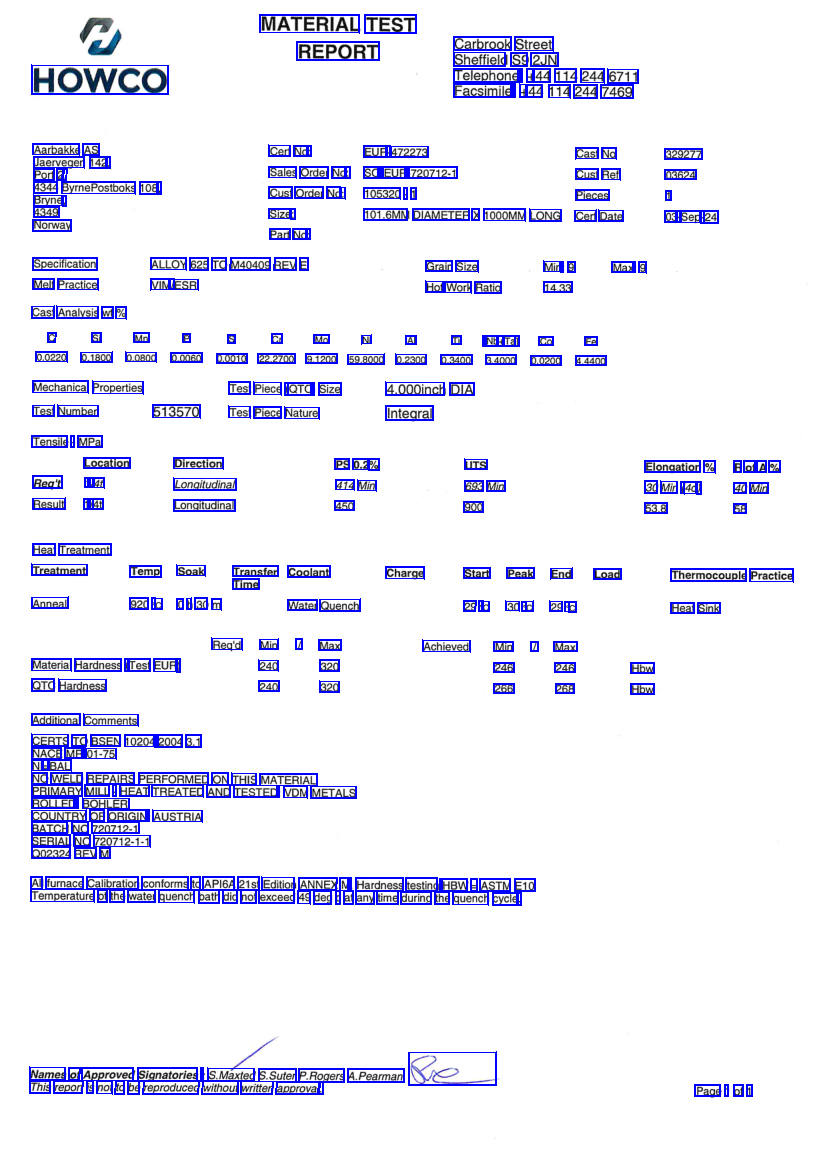

,content,confidence,offset,length,corner 1
0,HOWCO,0.972,2,5,"(0.3125, 0.6496)"
1,MATERIAL,0.996,24,8,"(2.5946, 0.1411)"
2,TEST,0.998,33,4,"(3.6488, 0.1451)"
3,REPORT,0.996,38,6,"(2.9698, 0.419)"
4,Carbrook,0.998,46,8,"(4.5355, 0.3614)"
5,Street,0.998,55,6,"(5.1416, 0.3665)"
6,Sheffield,0.984,62,9,"(4.5314, 0.5177)"
7,S9,0.935,72,2,"(5.1025, 0.5211)"
8,2JN,0.897,75,3,"(5.3078, 0.5222)"
9,Telephone,0.998,79,9,"(4.5314, 0.6823)"


In [10]:
print(f"Page {page.page_number}: {page.width} x {page.height} {doc.unit.value}, rotation {page.angle:.2f} degrees\n")

show_boxes([w.source for w in page.words], color="blue")

# First 12 words as a sample; 'corner 1' is the decoded top-left point of the polygon in `source`.
pd.DataFrame(
    [{"content": w.content, "confidence": w.confidence, "offset": w.span.offset,
      "length": w.span.length, "corner 1": polygons(w.source)[0][1][0]} for w in page.words[:12]]
)

`lines[]` groups words that sit on the same visual line. Each line has `content`, `span` and `source`, like a word but without `confidence`.

153 lines on the page; first 5:
  'HOWCO'
  'MATERIAL TEST'
  'REPORT'
  'Carbrook Street'
  'Sheffield S9 2JN'


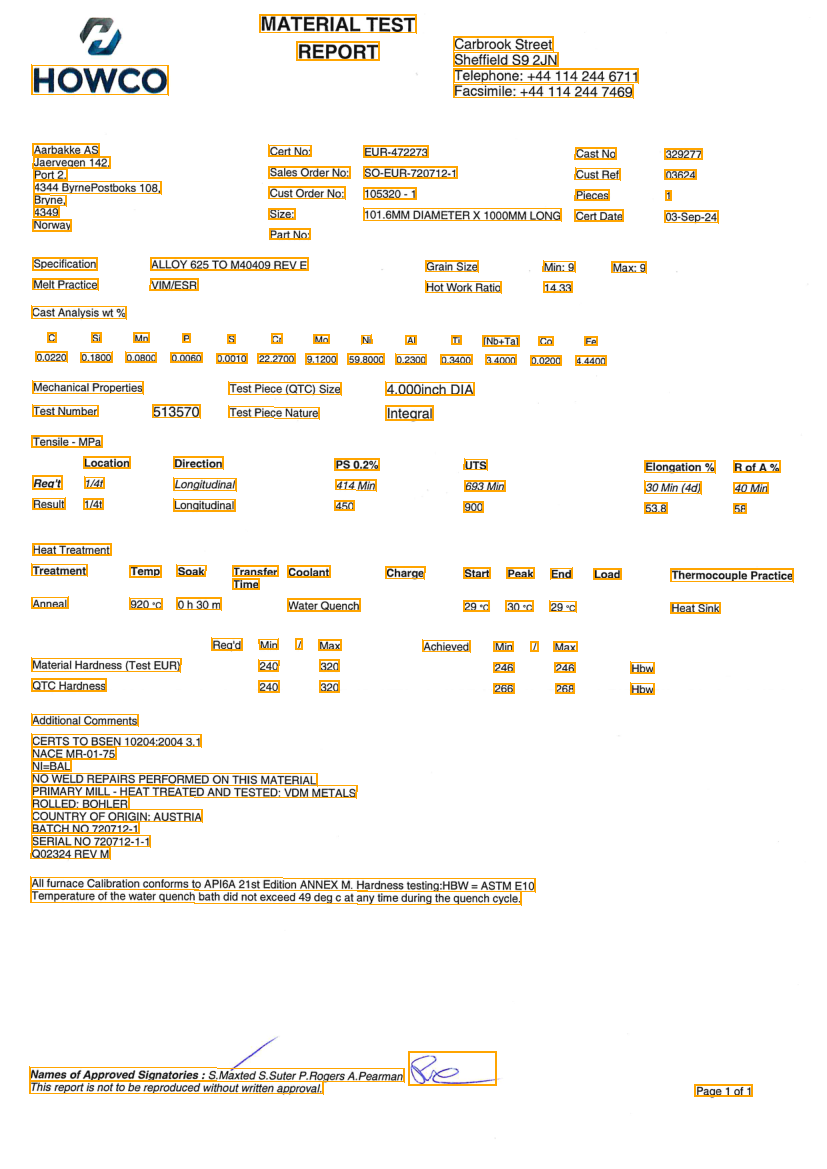

In [11]:
lines = page.lines or []
print(f"{len(lines)} lines on the page; first 5:")
for ln in lines[:5]:
    print(" ", repr(ln.content))

show_boxes([ln.source for ln in lines], color="orange")

`span` and `confidence` together: a word's `span` slices that word out of `markdown`, and `confidence` tells you when to doubt it. The cell below takes the lowest-confidence word on the page, slices it from `markdown`, and shows where it is. Low-confidence words are usually small marks, stamps or noise, not real text.

word.content = 'Pe'   confidence = 0.185
markdown[3211:3213] = 'Pe'


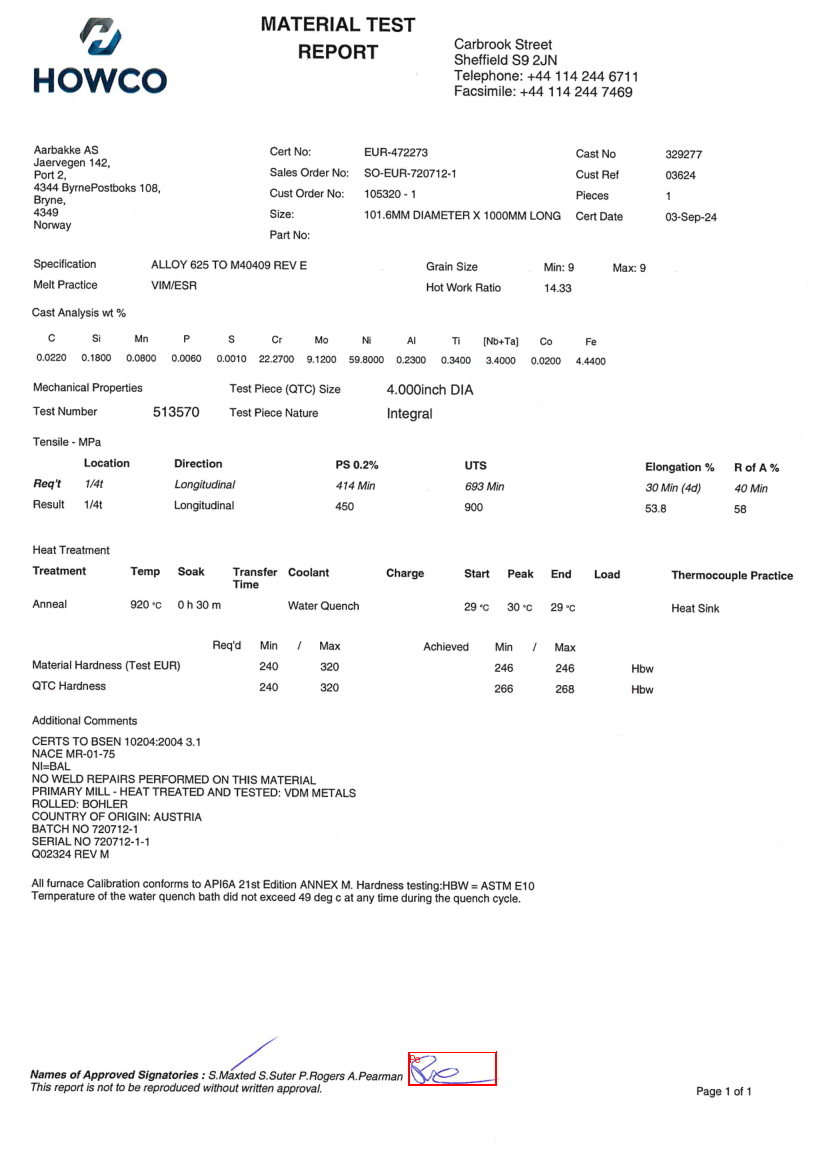

In [12]:
w = min(page.words, key=lambda w: w.confidence)

sliced = doc.markdown[w.span.offset : w.span.offset + w.span.length]
print(f"word.content = {w.content!r}   confidence = {w.confidence}")
print(f"markdown[{w.span.offset}:{w.span.offset + w.span.length}] = {sliced!r}")

show_boxes([w.source], labels=[w.content], color="red")

## 9. `paragraphs[]`: text blocks with a role

Paragraphs group lines into text blocks. A few get a `role`: `title`, `sectionHeading`, `pageHeader`,
`pageFooter`, `pageNumber`, `footnote`, `formulaBlock`. On certificates most paragraphs have no role (`None`). They are
label/value fragments like `Cert No:` and `EUR-472273`.

None          135
pageNumber      1
Name: count, dtype: int64 



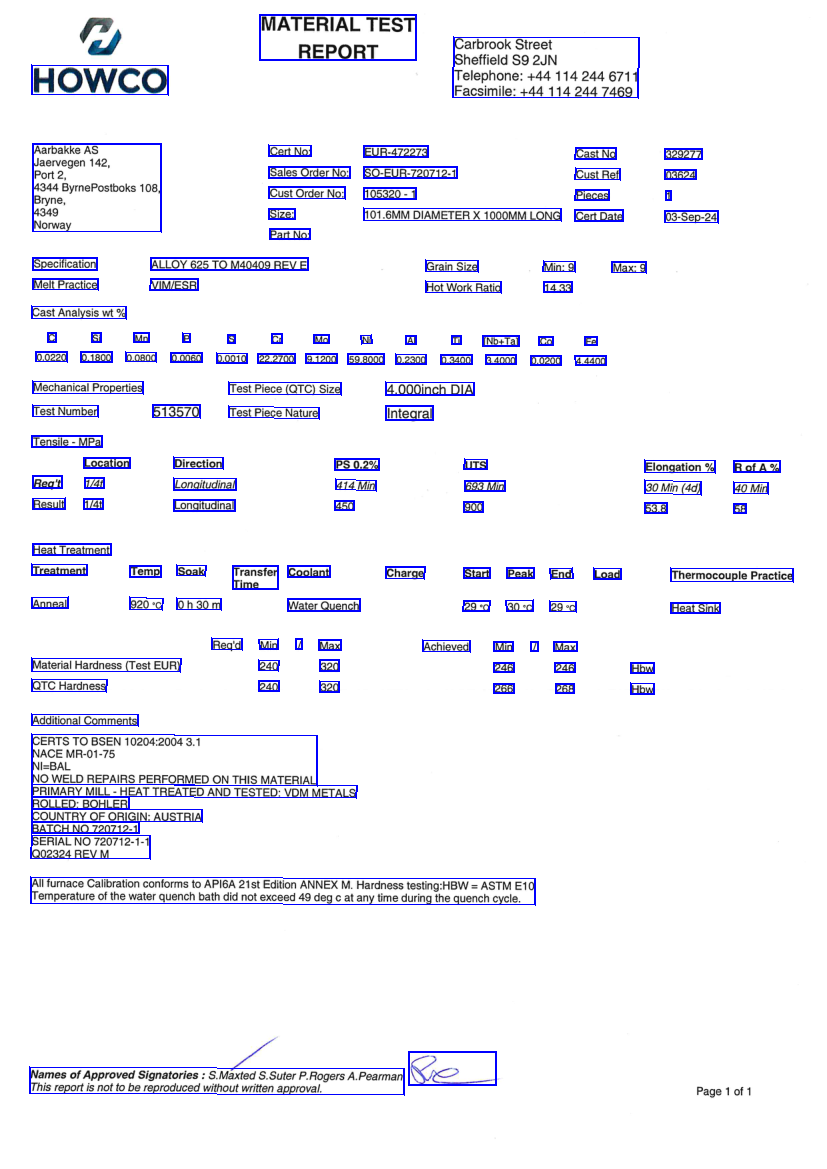

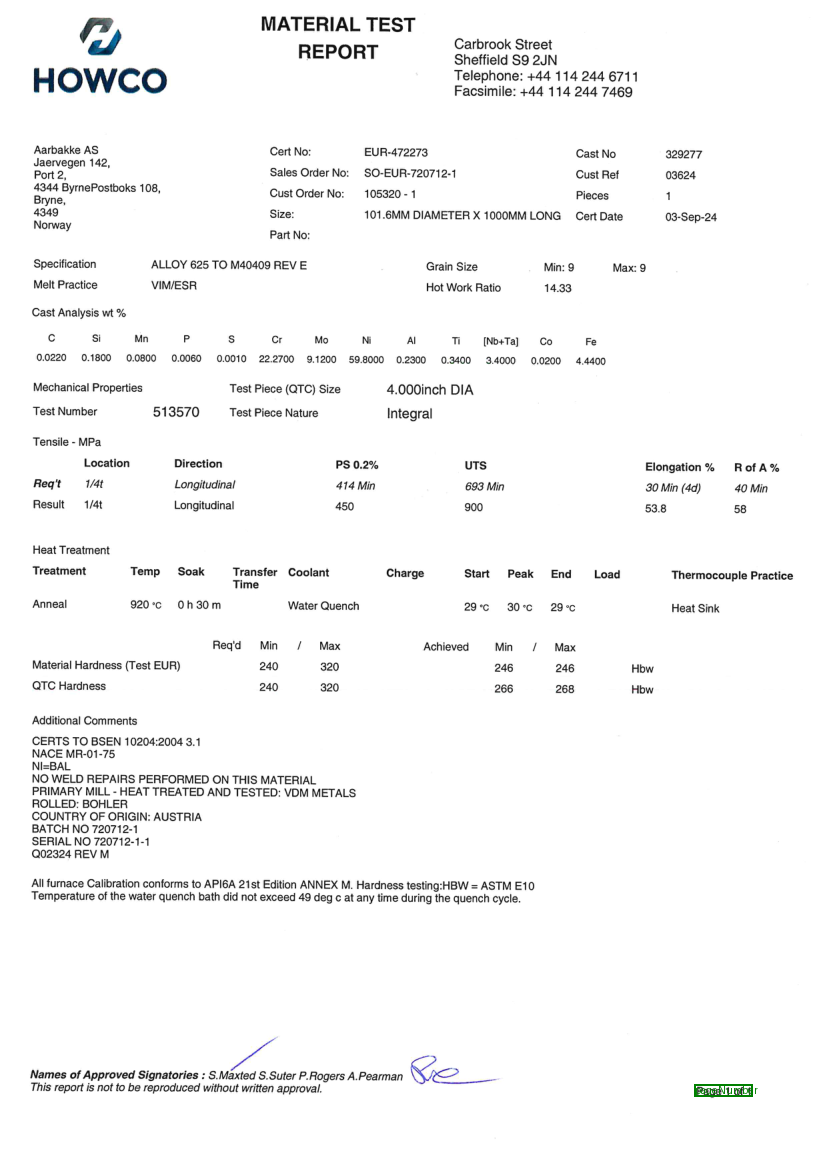

,role,content
0,None,HOWCO
1,None,MATERIAL TEST REPORT
2,None,Carbrook Street Sheffield S9 2JN Telephone: +4...
3,None,"Aarbakke AS Jaervegen 142, Port 2, 4344 ByrneP..."
4,None,Cert No:
5,None,EUR-472273
6,None,Cast No
7,None,329277
8,None,Sales Order No:
9,None,SO-EUR-720712-1


In [13]:
paragraphs = doc.paragraphs or []

# p.role is an enum or None; .value gives the string.
roles = pd.Series([p.role.value if p.role else None for p in paragraphs])
print(roles.value_counts(dropna=False), "\n")

# Blue = paragraphs without a role, green = paragraphs that have one.
show_boxes([p.source for p in paragraphs if not p.role], color="blue")
show_boxes([p.source for p in paragraphs if p.role], labels=[p.role.value for p in paragraphs if p.role], color="green")

# content is cut to 60 characters only to keep the table narrow.
pd.DataFrame([{"role": r, "content": p.content[:60]} for r, p in zip(roles, paragraphs)]).head(10)

## 9b. `sections[]` and element references

Elements point to each other with `elements`, a list of JSON pointers such as `/paragraphs/57` (index 57 in `paragraphs[]`).

- A **section** lists the elements it contains (paragraphs, tables, figures, nested sections). It is the document outline.
- A **table cell** points to the paragraph its text came from.

The helper `resolve` below follows a pointer in the raw JSON:

In [14]:
content = raw["contents"][0]  # raw JSON of the document

def resolve(pointer: str):
    """Follow a pointer like '/paragraphs/57' inside the content JSON."""
    _, collection, index = pointer.split("/")
    return content[collection][int(index)]

section = doc.sections[0]
print("section 0 elements (first 6):", section.elements[:6])

cell = doc.tables[0].cells[0]
print("\ntable 0, cell 0 text     :", repr(cell.content))
print("table 0, cell 0 elements :", cell.elements)
print("resolved paragraph       :", repr(resolve(cell.elements[0])["content"]))

section 0 elements (first 6): ['/figures/0', '/paragraphs/1', '/paragraphs/2', '/paragraphs/3', '/paragraphs/4', '/paragraphs/5']

table 0, cell 0 text     : 'Specification'
table 0, cell 0 elements : ['/paragraphs/21']
resolved paragraph       : 'Specification'


## 10. `tables[]`

Each table is a **flat list of cells**, not a grid:

| Table field | Meaning |
|---|---|
| `rowCount`, `columnCount` | Grid size |
| `cells[]` | One entry per cell |
| `source` / `span` | Where the whole table is on the page / in markdown. A table that continues across pages has more than one `D(...)` region in `source`, separated by `;`. |

| Cell field | Meaning |
|---|---|
| `rowIndex`, `columnIndex` | Position (0-based) |
| `rowSpan`, `columnSpan` | Merged cells |
| `kind` | `columnHeader`, `rowHeader`, `stubHead`, `description`, or `content` |
| `content` | The text in the cell |

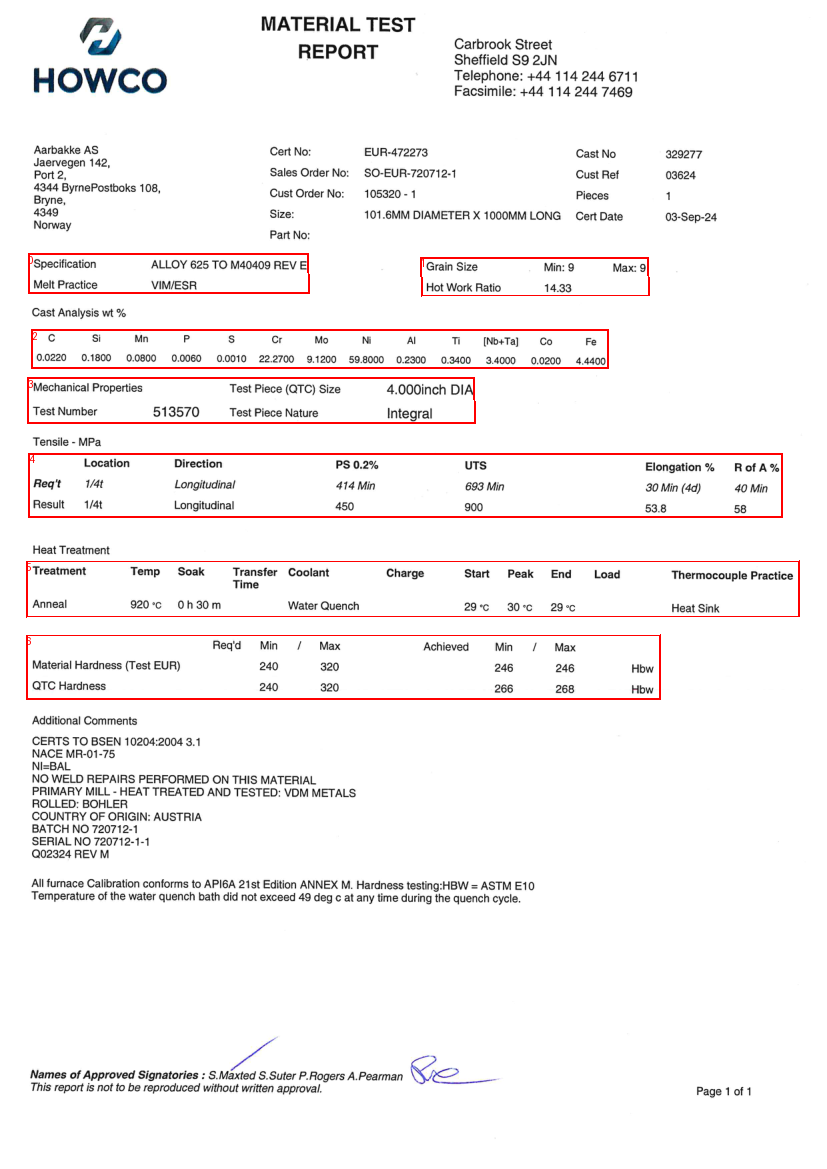

,table,page,rows,cols,first cells
0,0,1,2,2,Specification | ALLOY 625 TO M40409 REV E | Me...
1,1,1,2,3,Grain Size | Min: 9 | Max: 9 | Hot Work Ratio
2,2,1,2,13,C | Si | Mn | P
3,3,1,2,4,Mechanical Properties | Test Piece (QTC) Size ...
4,4,1,3,7,Location | Direction | PS 0.2% | UTS
5,5,1,2,11,Treatment | Temp | Soak | Transfer Time
6,6,1,3,10,Req'd | Min | / | Max


In [15]:
tables = doc.tables or []

# Every table on the page, labelled with its index.
show_boxes([t.source for t in tables], labels=[str(i) for i in range(len(tables))], color="red")

def preview(t, n=4):
    """First n non-empty cell values of a table."""
    return " | ".join([c.content for c in t.cells if c.content][:n])

pd.DataFrame(
    [{"table": i, "page": int(t.source.split(",")[0][2:]), "rows": t.row_count,
      "cols": t.column_count, "first cells": preview(t)} for i, t in enumerate(tables)]
)

Pick one table by its index in the overview (`TABLE_INDEX`). In the default PDF, table 4 is the tensile table. The box shows where it sits on the page, followed by its raw cells:

Table 4: 3 rows x 7 columns, 21 cells


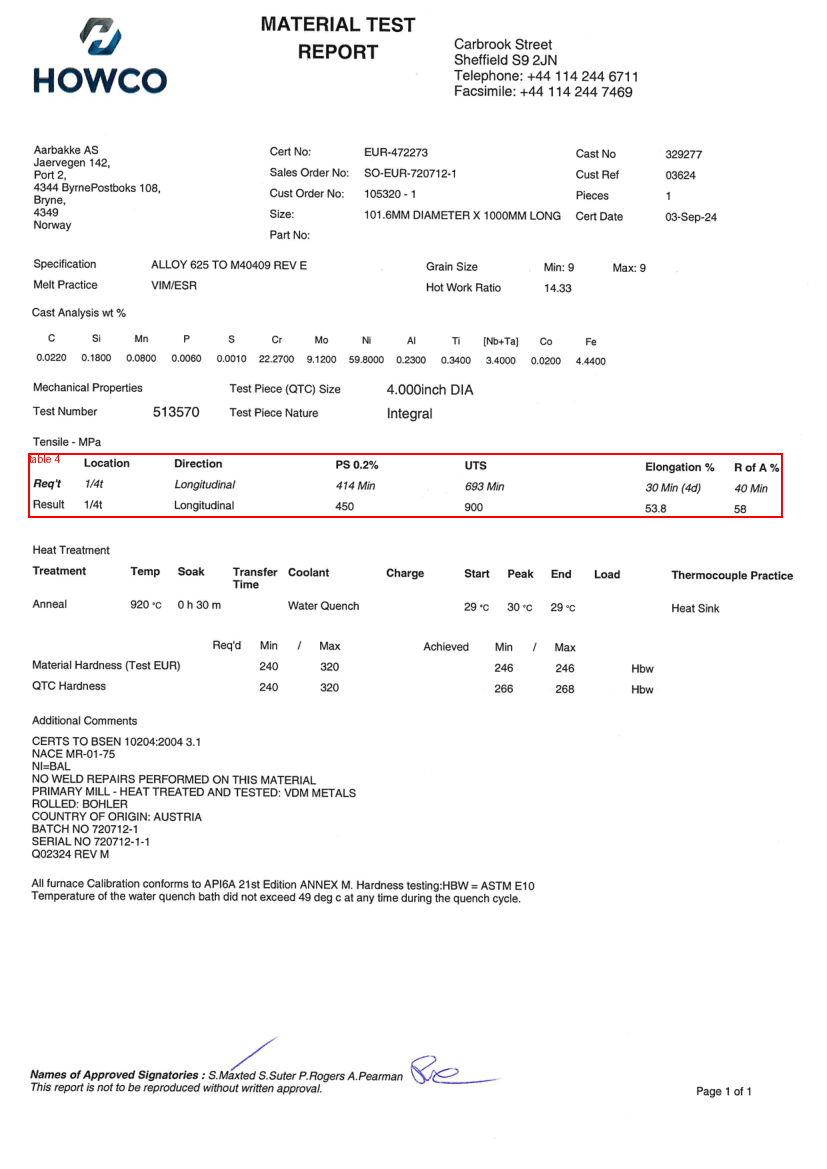

,row,col,kind,content
0,0,0,columnHeader,
1,0,1,columnHeader,Location
2,0,2,columnHeader,Direction
3,0,3,columnHeader,PS 0.2%
4,0,4,columnHeader,UTS
5,0,5,columnHeader,Elongation %
6,0,6,columnHeader,R of A %
7,1,0,content,Req't
8,1,1,content,1/4t
9,1,2,content,Longitudinal


In [16]:
TABLE_INDEX = 4  # tensile table in the default PDF; choose any index from the overview above
assert TABLE_INDEX < len(doc.tables), f"TABLE_INDEX must be between 0 and {len(doc.tables) - 1}"
table = doc.tables[TABLE_INDEX]

print(f"Table {TABLE_INDEX}: {table.row_count} rows x {table.column_count} columns, {len(table.cells)} cells")
show_boxes([table.source], labels=[f"table {TABLE_INDEX}"], color="red")

pd.DataFrame(
    [{"row": c.row_index, "col": c.column_index, "kind": c.kind.value, "content": c.content} for c in table.cells]
).head(15)

One cell, two views: the SDK object uses `snake_case` attributes, the REST JSON uses `camelCase` keys (`rowIndex`). Same data. `elements` is a link to the paragraph the text came from (see section 9b).

In [17]:
cell = table.cells[-1]

print("SDK object:", type(cell).__name__)
print("  cell.row_index =", cell.row_index, "| cell.column_index =", cell.column_index)
print("\nRaw JSON (result.as_dict()):")
print(json.dumps(cell.as_dict(), indent=2))

SDK object: DocumentTableCell
  cell.row_index = 2 | cell.column_index = 6

Raw JSON (result.as_dict()):
{
  "kind": "content",
  "rowIndex": 2,
  "columnIndex": 6,
  "rowSpan": 1,
  "columnSpan": 1,
  "content": "58",
  "source": "D(1,7.2308,4.975,7.8137,4.9789,7.8125,5.1862,7.2308,5.1822)",
  "span": {
    "offset": 1733,
    "length": 2
  },
  "elements": [
    "/paragraphs/84"
  ]
}


Rebuild the grid: place each cell with `rowIndex` / `columnIndex`, let merged cells cover their `rowSpan` / `columnSpan`, and use the `columnHeader` row as column names.

To see a merged cell in the default PDF, set `TABLE_INDEX = 3` above ("Mechanical Properties" spans 2 columns) and rerun from there.

In [18]:
# Place each cell at (row_index, column_index). row_span is None when the cell is not merged; a merged cell fills every position it spans.
grid = [[""] * table.column_count for _ in range(table.row_count)]
for c in table.cells:
    for r in range(c.row_index, c.row_index + (c.row_span or 1)):
        for k in range(c.column_index, c.column_index + (c.column_span or 1)):
            grid[r][k] = c.content

# Rows made of columnHeader cells become the column names; the rest is the body.
header_rows = sorted({c.row_index for c in table.cells if c.kind.value == "columnHeader"})
body = [row for i, row in enumerate(grid) if i not in header_rows]
columns = grid[header_rows[-1]] if header_rows else None

pd.DataFrame(body, columns=columns)

,,Location,Direction,PS 0.2%,UTS,Elongation %,R of A %
0,Req't,1/4t,Longitudinal,414 Min,693 Min,30 Min (4d),40 Min
1,Result,1/4t,Longitudinal,450,900,53.8,58


Layout gives the position of each value and which cells are headers. It does not say what a row *means*.

In the default PDF (`EUR-472273.pdf`, `TABLE_INDEX = 4`) the `Req't` row holds specification limits (414 / 693 MPa) and the `Result` row holds measured values (450 / 900 MPa), but nothing in the response labels them that way. That split is done in `notebooks/02-content-understanding-tables.ipynb`.

## 11. `figures[]`

Images such as logos and stamps are detected as figures. With `enableFigureDescription` off there is no caption,
only the id (`page.index`, matching `![alt](figures/1.1)` in `markdown`) and the location, drawn below.

1 figure(s)


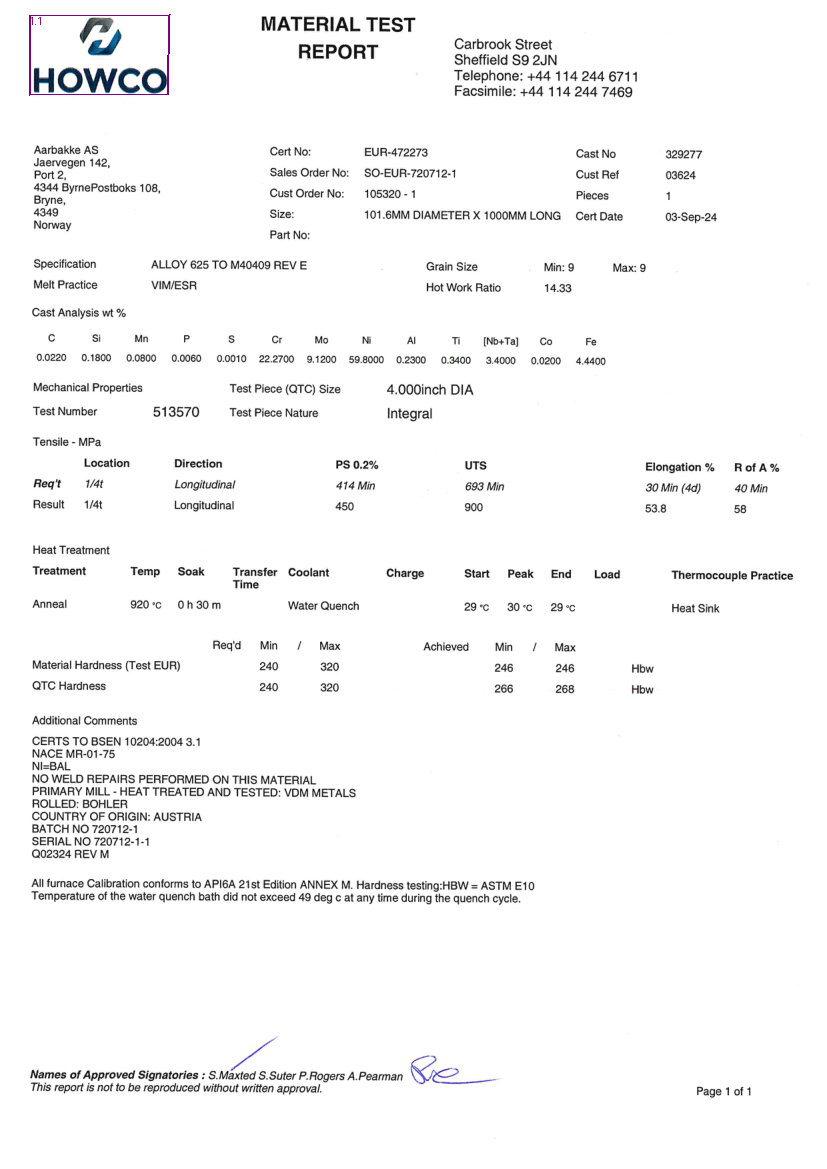

In [19]:
figures = doc.figures or []
print(f"{len(figures)} figure(s)")

show_boxes([f.source for f in figures], labels=[f.id for f in figures], color="purple")

## 12. When a call fails

Errors come back as HTTP status codes with a JSON `error` body. The SDK raises `HttpResponseError`.

| Status | Usual cause |
|---|---|
| 401 | Wrong or missing key |
| 404 | Wrong endpoint, or unknown analyzer id |
| 400 | Bad `range`, wrong `Content-Type`, unsupported file |

The cell below requests an analyzer that does not exist (no billing):

In [20]:
# Ask for an analyzer that does not exist. Free: nothing is analyzed or billed.
try:
    client.get_analyzer("no-such-analyzer")
except HttpResponseError as err:
    print("HTTP status :", err.status_code)
    print("error code  :", err.error.code if err.error else None)
    print("message     :", err.message)

HTTP status : 404
error code  : NotFound
message     : (NotFound) Resource not found.
Code: NotFound
Message: Resource not found.
Inner error: {
    "code": "ModelNotFound",
    "message": "Analyzer 'no-such-analyzer' was not found."
}


## 13. Where each field lives

| Need | SDK | JSON path |
|---|---|---|
| All text as Markdown | `doc.markdown` | `contents[0].markdown` |
| Page count | `doc.end_page_number` | `contents[0].endPageNumber` |
| Words with confidence | `doc.pages[i].words` | `contents[0].pages[i].words[]` |
| Text blocks / headings | `doc.paragraphs` (`.role`) | `contents[0].paragraphs[]` |
| Tables as cells | `doc.tables[i].cells` | `contents[0].tables[i].cells[]` |
| Which page a table is on | first number in `table.source` | `D(<page>, ...)` |
| Where an element is in the text | `.span.offset` / `.span.length` | `span` |
| Lines of text | `doc.pages[i].lines` | `contents[0].pages[i].lines[]` |
| Where an element is on the page | `.source` (`D(page, x1,y1, ... x4,y4)`) | `source` |
| Page(s) of a table | every `D(<page>, ...)` region in `table.source` (more than one if it continues across pages) | `contents[0].tables[i].source` |
| Link from one element to another | `.elements` (JSON pointers such as `/paragraphs/57`) | `elements` |
| Images / logos / stamps | `doc.figures` | `contents[0].figures[]` |
| Raw JSON | `result.as_dict()` | the result object |

**Swap the PDF:** change `PDF_PATH` (and `PAGE`) in Setup and run again. Pick a new `TABLE_INDEX` from the table overview in section 10.

`prebuilt-layout` returns text, positions, confidence, table grids, header kinds, and figures. Field meaning (heat number, spec vs result) is notebook 02 or a custom analyzer with a field schema.

**Next steps**

- `notebooks/02-content-understanding-tables.ipynb`: full documents, spec vs result rows, HTML reports
- [Create a custom analyzer](https://learn.microsoft.com/en-us/azure/ai-services/content-understanding/tutorial/create-custom-analyzer): extract named fields with an LLM
- [Document elements reference](https://learn.microsoft.com/en-us/azure/ai-services/content-understanding/document/elements)